# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Proyecto final - Código de solución

Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos. <br />
<br />
Servicios de Interconnect <br />
<br />
Interconnect proporciona principalmente dos tipos de servicios:<br />
1.	Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea. <br />
2.	Internet. La red se puede configurar a través de una línea telefónica (DSL, línea de abonado digital) o a través de un cable de fibra óptica.
Algunos otros servicios que ofrece la empresa incluyen: <br />
•	Seguridad en Internet: software antivirus (ProtecciónDeDispositivo) y un bloqueador de sitios web maliciosos (SeguridadEnLínea).<br />
•	Una línea de soporte técnico (SoporteTécnico).<br />
•	Almacenamiento de archivos en la nube y backup de datos (BackupOnline).<br />
•	Streaming de TV (StreamingTV) y directorio de películas (StreamingPelículas)<br />
<br />
La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción. <br />

## Descripción de los datos

Los datos consisten en archivos obtenidos de diferentes fuentes:<br />
•	contract.csv — información del contrato; <br />
•	personal.csv — datos personales del cliente; <br />
•	internet.csv — información sobre los servicios de Internet; <br />
•	phone.csv — información sobre los servicios telefónicos. <br />
<br />
En cada archivo, la columna customerID (ID de cliente) contiene un código único asignado a cada cliente. La información del contrato es válida a partir del 1 de febrero de 2020.


## Análisis exploratorio de datos

In [54]:
# importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier



In [2]:
# carga de archivos
df_contract = pd.read_csv('/datasets/final_provider/contract.csv')
df_internet = pd.read_csv('/datasets/final_provider/internet.csv')
df_personal = pd.read_csv('/datasets/final_provider/personal.csv')
df_phone = pd.read_csv('/datasets/final_provider/phone.csv')

### Análisis de cada df

#### df contract

In [3]:
# contract
df_contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [4]:
df_contract.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65
5,9305-CDSKC,2019-03-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,99.65,820.5
6,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,301.9
8,7892-POOKP,2017-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,104.80,3046.05
9,6388-TABGU,2014-12-01,No,One year,No,Bank transfer (automatic),56.15,3487.95


In [5]:
df_contract.shape

(7043, 8)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La exploración inicial de los datos está presentada de forma ordenada y clara, mostrando correctamente la estructura, dimensiones y tipos de variables del conjunto principal. Esto facilita comprender el contexto del proyecto desde el inicio.
</div>

In [6]:
# conversión a formatos adecuados
df_contract['BeginDate'] = pd.to_datetime(df_contract['BeginDate'], errors='coerce', format='%Y-%m-%d')
df_contract['EndDate'] = pd.to_datetime(df_contract['EndDate'], errors='coerce', format='%Y-%m-%d')
df_contract['TotalCharges'] = pd.to_numeric(df_contract['TotalCharges'], errors='coerce')

In [7]:
print(f"Número de valores ausentes: \n{df_contract.isna().sum()}")

print(f'Número de valores duplicados: {df_contract.duplicated().sum()}')

Número de valores ausentes: 
customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
dtype: int64
Número de valores duplicados: 0


In [8]:
# describe para conocer el comportamiento de las columnas numéricas
df_contract.describe()

,MonthlyCharges,TotalCharges
count,7043.000000,7032.000000
mean,64.761692,2283.300441
std,30.090047,2266.771362
min,18.250000,18.800000
25%,35.500000,401.450000
50%,70.350000,1397.475000
75%,89.850000,3794.737500
max,118.750000,8684.800000


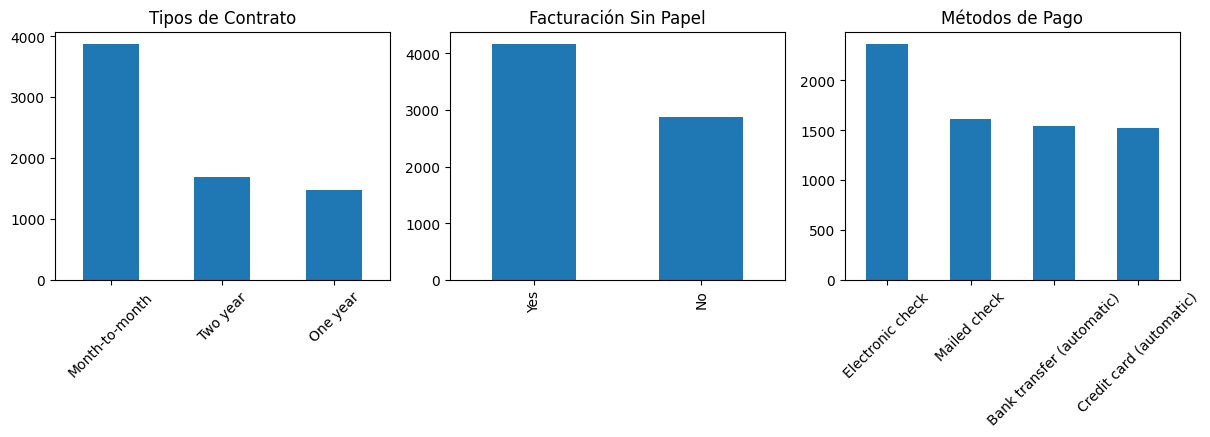

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
df_contract['Type'].value_counts().plot(kind='bar')
plt.title('Tipos de Contrato')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
df_contract['PaperlessBilling'].value_counts().plot(kind='bar')
plt.title('Facturación Sin Papel')
plt.tight_layout()

plt.subplot(1, 3, 3)
df_contract['PaymentMethod'].value_counts().plot(kind='bar')
plt.title('Métodos de Pago')
plt.xticks(rotation=45)
plt.show()

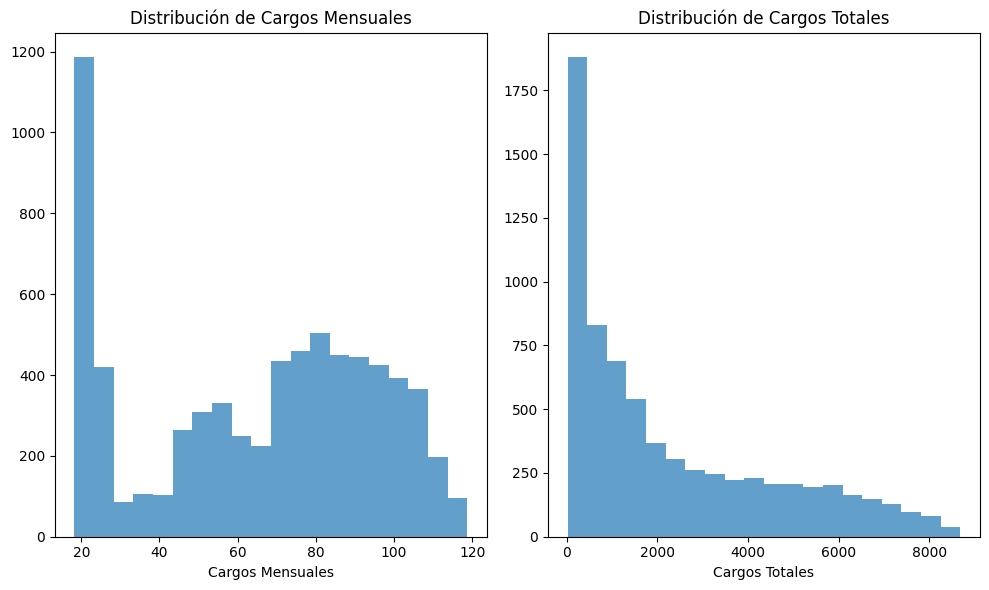

In [10]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(df_contract['MonthlyCharges'], bins=20, alpha=0.7)
plt.title('Distribución de Cargos Mensuales')
plt.xlabel('Cargos Mensuales')

plt.subplot(1, 2, 2)
plt.hist(df_contract['TotalCharges'].dropna(), bins=20, alpha=0.7)
plt.title('Distribución de Cargos Totales')
plt.xlabel('Cargos Totales')
plt.tight_layout()
plt.show()

El df contract cuenta con un tamaño de 7043 filas y 8 columnas, cada fila correspondiente a un usuario. Se evidencian columnas con formato incorrecto (BeginDate y EndDate), al cambiar el formato de EndDate ya presenta valores ausentes (5174); la columan TotalCharges también cuenta con un formato incorrecto, que al cambiarlo presenta valores ausentes (11). 
<br />
Se realizan las gráficas de las columnas para estudiar el comportamiento de los datos. En el tipo de contratos se observa que la mayoría de los usuarios prefieren realizar pagos mensuales, en contraste con alrededor de un 20% que prefiere firmar contratos anuales. Con respecto a la facturación, cerca del 60% optan por una facturación electrónica y menos de la mitad de los clientes por facturación física. Referente a los métodos de pago, se observa un comportamiento similar, aunque sobresale el pago por métodos electrónicos, yendo muy acorde con el tipo de facturación. 
<br />
Pasando a los cargos mensuales, se observa que cerca del 17% de clientes pagan la tarifa mínima de servicios. El promedio de pago mensual es de 64.76 USD, valor inferior a la mediana.
<br />
Para los cargos totales, se puede determinar una asimetría positiva, con un promedio superior a la mediana. Esto se corrobora al revisar el histograma, con el pico más alto de cerca del 25% de clientes, a los cuales se les llegó a cobrar entre 18 hasta 500 USD. A su vez, se observan algunos valores atípicos de frecuencias bajas a partir de los 7000 USD.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La conversión de tipos de datos y el análisis descriptivo muestran una revisión detallada del conjunto de datos. La interpretación de las distribuciones y comportamientos observados aporta claridad y contexto al análisis exploratorio.
</div>

#### df personal

In [11]:
df_personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [12]:
df_personal.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes


In [13]:
df_personal.shape

(7043, 5)

In [14]:
print(f"Número de valores ausentes: \n{df_personal.isna().sum()}")

print(f'Número de valores duplicados: {df_personal.duplicated().sum()}')

Número de valores ausentes: 
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64
Número de valores duplicados: 0


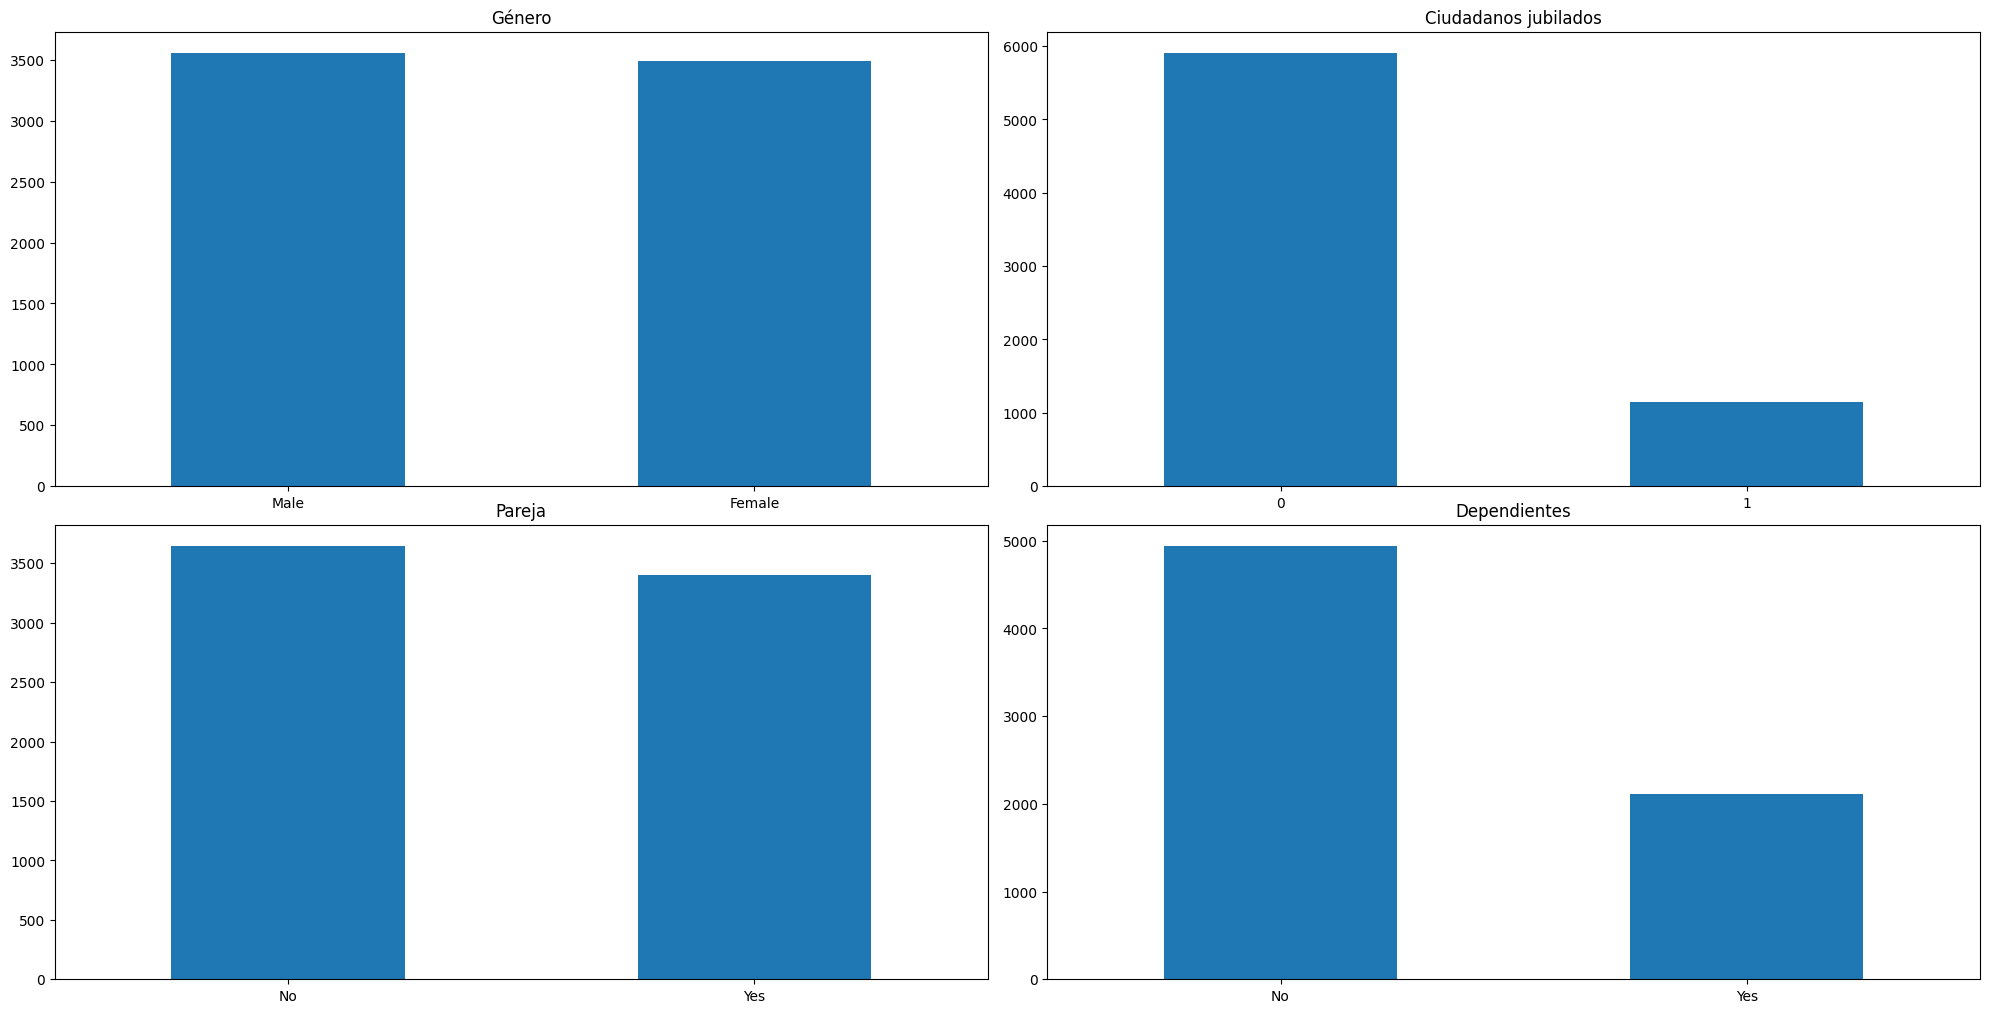

In [15]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
df_personal['gender'].value_counts().plot(kind='bar')
plt.title('Género')
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
df_personal['SeniorCitizen'].value_counts().plot(kind='bar')
plt.title('Ciudadanos jubilados')
plt.tight_layout()
plt.xticks(rotation=0)

plt.subplot(2, 2, 3)
df_personal['Partner'].value_counts().plot(kind='bar')
plt.title('Pareja')
plt.xticks(rotation=0)

plt.subplot(2, 2, 4)
df_personal['Dependents'].value_counts().plot(kind='bar')
plt.title('Dependientes')
plt.xticks(rotation=0)
plt.show()

El df personal cuenta con un tamaño de 7043 filas y 5 columnas, no presenta datos ausentes ni duplicados. El género se encuentra en una proporción igual para hombres y mujeres. Solo alrededor del 20% de los usuarios son pensionados y la cantidad de usuarios sin pareja es un poco superior a los que si tienen. Referente a los dependientes, cerca del 70% de los usuarios no presentan. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La revisión del conjunto de datos personales está bien estructurada y las visualizaciones permiten identificar rápidamente las características principales de los clientes y su distribución demográfica.
</div>

#### df internet

In [16]:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [17]:
df_internet.head(10)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [18]:
df_internet.shape

(5517, 8)

In [19]:
print(f"Número de valores ausentes: \n{df_internet.isna().sum()}")

print(f'Número de valores duplicados: {df_internet.duplicated().sum()}')

Número de valores ausentes: 
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64
Número de valores duplicados: 0


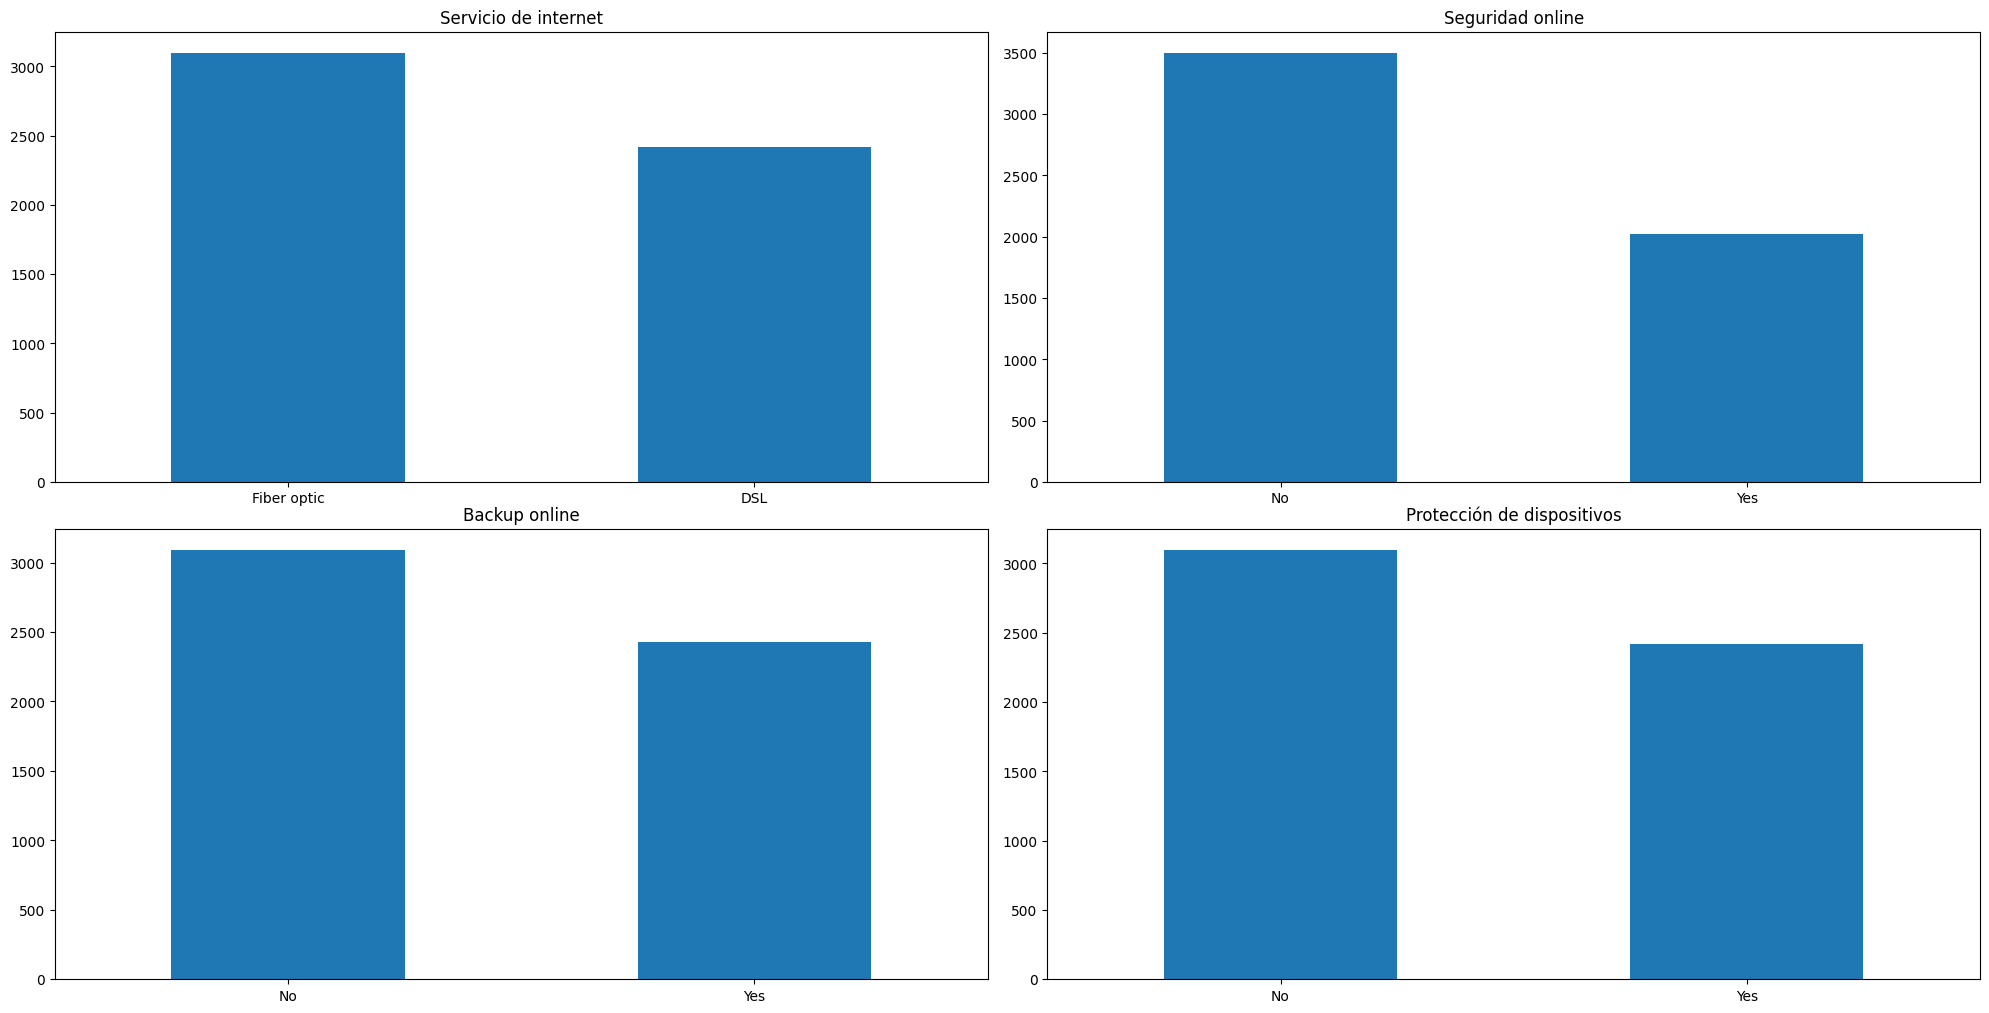

In [20]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
df_internet['InternetService'].value_counts().plot(kind='bar')
plt.title('Servicio de internet')
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
df_internet['OnlineSecurity'].value_counts().plot(kind='bar')
plt.title('Seguridad online')
plt.tight_layout()
plt.xticks(rotation=0)

plt.subplot(2, 2, 3)
df_internet['OnlineBackup'].value_counts().plot(kind='bar')
plt.title('Backup online')
plt.xticks(rotation=0)

plt.subplot(2, 2, 4)
df_internet['DeviceProtection'].value_counts().plot(kind='bar')
plt.title('Protección de dispositivos')
plt.xticks(rotation=0)
plt.show()

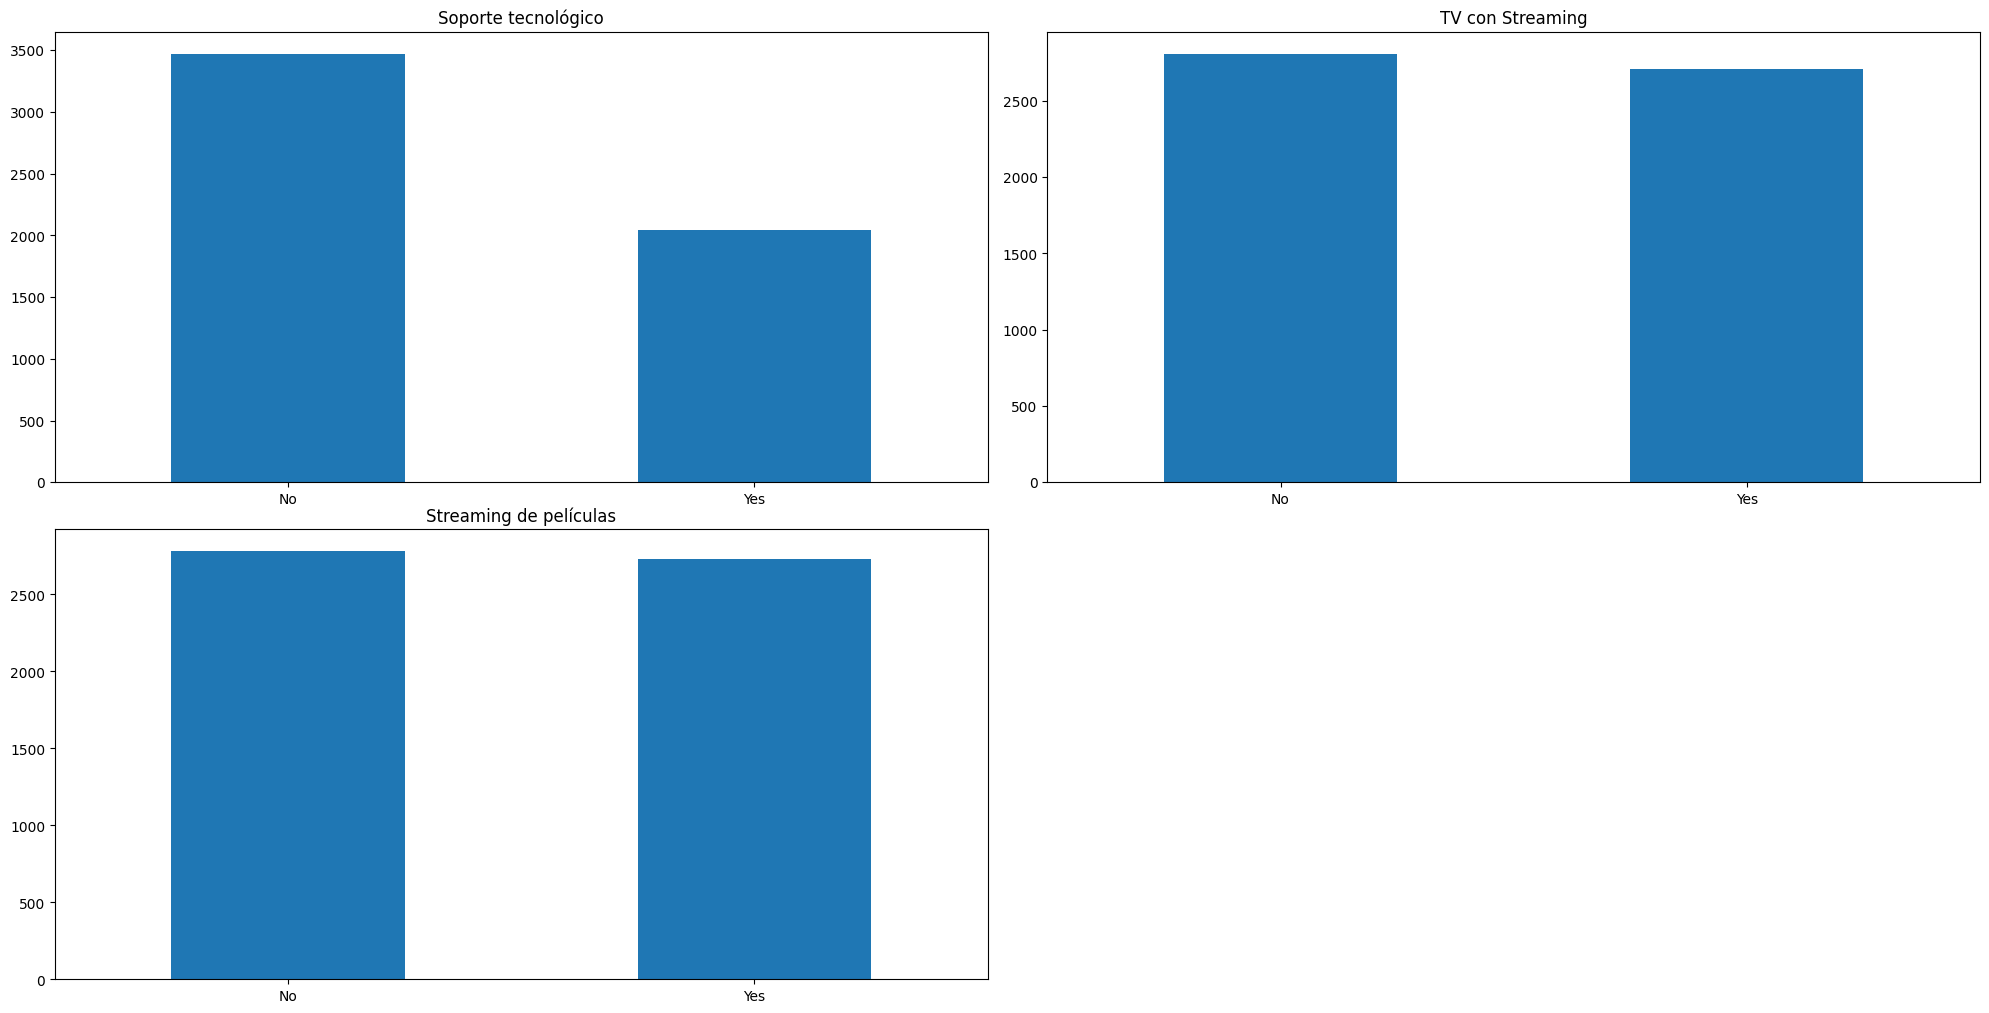

In [21]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
df_internet['TechSupport'].value_counts().plot(kind='bar')
plt.title('Soporte tecnológico')
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
df_internet['StreamingTV'].value_counts().plot(kind='bar')
plt.title('TV con Streaming')
plt.tight_layout()
plt.xticks(rotation=0)

plt.subplot(2, 2, 3)
df_internet['StreamingMovies'].value_counts().plot(kind='bar')
plt.title('Streaming de películas')
plt.xticks(rotation=0)
plt.show()

El df internet cuenta con un tamaño de 5517 filas y 8 columnas, no presenta datos ausentes ni duplicados. Más del 50% de los usuarios prefieren los servicios de fibra óptica, posiblemente por su velocidad. Para los servicios adicionales de seguridad online, backup de datos, protección de dispositivos y soporte técnico, se observa que cerca de un 60% de los usuarios no usa estos servicios. Referente a los temas de streaming, tanto películas como TV, están cerca de un 50/50, aunque predomina levemente el no uso de estos servicios.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El análisis del conjunto de servicios de internet está bien documentado y las observaciones realizadas sobre las preferencias de los clientes reflejan una interpretación clara de los datos obtenidos.
</div>

#### df phone

In [22]:
df_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [23]:
df_phone.head(10)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


In [24]:
df_phone.shape

(6361, 2)

In [25]:
print(f"Número de valores ausentes: \n{df_phone.isna().sum()}")

print(f'Número de valores duplicados: {df_phone.duplicated().sum()}')

Número de valores ausentes: 
customerID       0
MultipleLines    0
dtype: int64
Número de valores duplicados: 0


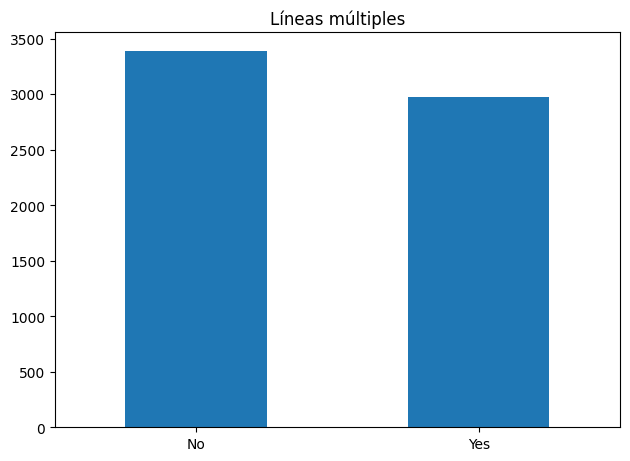

In [26]:
df_phone['MultipleLines'].value_counts().plot(kind='bar')
plt.title('Líneas múltiples')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

El df phone cuenta con un tamaño de 6361 filas y 2 columnas, no presenta valores ausentes ni duplicados. Se identifica que la mayor proporción de usuarios (55%) no tiene líneas múltiples, aunque para ser un servicio que ya casi no se utiliza, un porcentaje significativo todavía si conserva esto.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La revisión del conjunto de datos telefónicos mantiene una estructura clara y una interpretación consistente de los resultados observados, facilitando la comprensión del comportamiento de los usuarios.
</div>

## Procesamiento de datos

Se sabe que se cuenta con la información de 7043 usuarios, aunque los df de internet (5517) y teléfono (6361) tienen menos datos, indicando que no todos los usuarios hacen uso de estos servicios, algo que se debe tener en cuenta si se va a unificar la información en un dataset.
<br />
Como el objetivo es conocer la fecha final del contrato, la columna EndDate sería el target, por lo que se debe volver numérica para proceder con los análisis (0 no cancela contrato, 1 cancela contrato).
<br />
Una vez unificado el df, se debe estudiar la relación de cada una de las columnas con el objetivo que es la no cancelación del contrato, además de tener en cuenta el porqué la mayoría de los usuarios no utiliza los servicios adicionales que se ofertan con el internet principalmente.

### Creación de df combinado

In [27]:
# combinación de los cuatro dataframe con la función merge LEFT
df = (df_contract.merge(df_personal, how='left', on='customerID')
      .merge(df_internet, how='left', on='customerID')
      .merge(df_phone, how='left', on='customerID')    
)

df.head(10)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
5,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes
6,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes
7,6713-OKOMC,2019-04-01,NaT,Month-to-month,No,Mailed check,29.75,301.90,Female,0,No,No,DSL,Yes,No,No,No,No,No,NaN
8,7892-POOKP,2017-07-01,2019-11-01,Month-to-month,Yes,Electronic check,104.80,3046.05,Female,0,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Yes
9,6388-TABGU,2014-12-01,NaT,One year,No,Bank transfer (automatic),56.15,3487.95,Male,0,No,Yes,DSL,Yes,Yes,No,No,No,No,No


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

### Modificación de columnas en el nuevo df

In [29]:
# definición de la variable objetivo a partir de EndDate, 
# ya que indica cuando un usuario se ha retirado
df['exited'] = df['EndDate'].notna().astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [30]:
df['exited'].value_counts(dropna=False)

0    5174
1    1869
Name: exited, dtype: int64

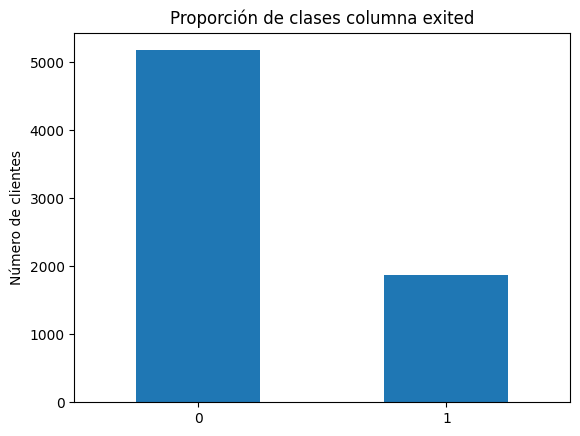

In [31]:
df['exited'].value_counts().plot(kind='bar', rot=0)
plt.title('Proporción de clases columna exited')
plt.ylabel('Número de clientes')
plt.show()

Se observa un desbalance en el target, siendo 73% no y 27% si en la cancelación de los planes

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La integración de los conjuntos de datos y la construcción de la variable objetivo están desarrolladas de manera clara y coherente, mostrando una comprensión adecuada del problema y de la preparación necesaria para el modelado.
</div>

### Preparación de datos

In [32]:
# reemplazo de NaT en columna EndDate
print(f"Fecha mínima de inicio contrato: {df['BeginDate'].max()}")
# este sería el valor máximo

df['EndDate'] = df['EndDate'].fillna('2020-02-01')
df['EndDate'] = pd.to_datetime(df['EndDate'])


Fecha mínima de inicio contrato: 2020-02-01 00:00:00


In [33]:
# Se reemplaza NaT por la fecha máxima presente en el df
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [34]:
# valores ausentes en TotalCharges con el valor de cargo mensual
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = df['MonthlyCharges']
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [35]:
# columnas en las que el usuario no usa dicho servicio
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
        'StreamingTV', 'StreamingMovies', 'MultipleLines']
#df.head(20)
# se reemplazan por no_service porque "No" ya se utiliza como variable
for col in cols:
    df[col] = df[col].fillna('no_service')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

In [36]:
# eliminación de columnas que no son necesarias
df_final = df.drop(columns=['customerID', 'BeginDate', 'EndDate'])
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   object 
 1   PaperlessBilling  7043 non-null   object 
 2   PaymentMethod     7043 non-null   object 
 3   MonthlyCharges    7043 non-null   float64
 4   TotalCharges      7043 non-null   float64
 5   gender            7043 non-null   object 
 6   SeniorCitizen     7043 non-null   int64  
 7   Partner           7043 non-null   object 
 8   Dependents        7043 non-null   object 
 9   InternetService   5517 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  MultipleLines     7043 non-null   object 


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La preparación de los datos está desarrollada de manera consistente y organizada, resolviendo adecuadamente los valores ausentes y dejando el conjunto final listo para el proceso de modelado.
</div>

### Normalización de datos

In [37]:
# One-hot encoding para las variables categóricas
df_ohe = pd.get_dummies(df_final, drop_first=True)

In [38]:
# Normalización por StandardScaler para las variables numéricas
num_features = ['MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
scaler.fit(df_ohe[num_features])
df_ohe[num_features] = scaler.transform(df_ohe[num_features])
df_ohe.head()

,MonthlyCharges,TotalCharges,SeniorCitizen,exited,Type_One year,Type_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,DeviceProtection_Yes,DeviceProtection_no_service,TechSupport_Yes,TechSupport_no_service,StreamingTV_Yes,StreamingTV_no_service,StreamingMovies_Yes,StreamingMovies_no_service,MultipleLines_Yes,MultipleLines_no_service
0,-1.160323,-0.992667,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1,-0.259629,-0.172198,0,0,1,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
2,-0.362660,-0.958122,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,-0.746535,-0.193706,0,0,1,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,1
4,0.197365,-0.938930,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La transformación de variables categóricas y la normalización de los datos fueron aplicadas correctamente, dejando el conjunto preparado de forma adecuada para el entrenamiento de modelos de machine learning.
</div>

### Entrenamiento de modelos

In [47]:
# para agilizar el procedimiento se hace la estrategia de 
# definición de funciones

# model_gridsearch: identificación de los mejores hiperparámetros y métrica
def model_gridsearch(estimator, params, features_train, target_train, model_name):
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=params,
        scoring='roc_auc',
        cv=5
    )
    
    grid_search.fit(features_train, target_train)

    max_score = grid_search.cv_results_['mean_test_score'].max()
    index_max_score = np.where(grid_search.cv_results_['mean_test_score']==max_score)[0][0]

    best_set_params = grid_search.cv_results_['params'][index_max_score]

    print(f"Mejores hiperparámetros {model_name}:\n {best_set_params}")
    print(f"Mejor AUC-ROC {model_name}: {max_score}")
    

In [40]:
# evaluate_model: identificación de métricas AUC-ROC y exactitud para 
# entrenamiento y prueba
def evaluate_model(model, train_features, train_target, test_features, test_target, model_name):
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.1)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]  
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales        
        for threshold in ( 0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')  
        
        eval_stats[type]['Exactitud'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target, zero_division=0)
        eval_stats[type]['Precisión'] = metrics.precision_score(target, pred_target, zero_division=0)
        eval_stats[type]['Sensibilidad'] = metrics.recall_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(4)
    df_eval_stats = df_eval_stats.reindex(index=('Exactitud', 'Sensibilidad', 'Precisión', 'F1', 'APS', 'ROC AUC'))
    
    print(f'{model_name}:')
    print(df_eval_stats)   
    

In [55]:
# cf_matrix devuelve la matriz de confusión para el conjunto de entrenamiento
# y prueba
def cf_matrix(model, train_features, train_target, test_features, test_target, model_name): 
   
    # Definimos el número y tamaño de subplots
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    # matriz de confusión para el conjunto de entrenamiento
    ax = axs[0]
    cm = confusion_matrix(train_target, model.predict(train_features))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=ax)
    ax.set_title('Entrenamiento')
    ax.grid(False)
    
    # matriz de confusión para el conjunto de prueba
    ax = axs[1]
    cm = confusion_matrix(test_target, model.predict(test_features))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=ax)
    ax.set_title('Prueba')
    ax.grid(False)
    
    plt.suptitle(f'Matrices de confusión {model_name}')

In [42]:
# establecimiento de características y objetivo
features = df_ohe.drop(columns='exited')
target = df_ohe['exited']

# división de los datos en 80/20 entrenamiento/prueba
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=12345)

### Modelo dummy

Modelo dummy:
               train   test
Exactitud     0.7355  0.731
Sensibilidad  0.0000  0.000
Precisión     0.0000  0.000
F1            0.0000  0.000
APS           0.2645  0.269
ROC AUC       0.5000  0.500


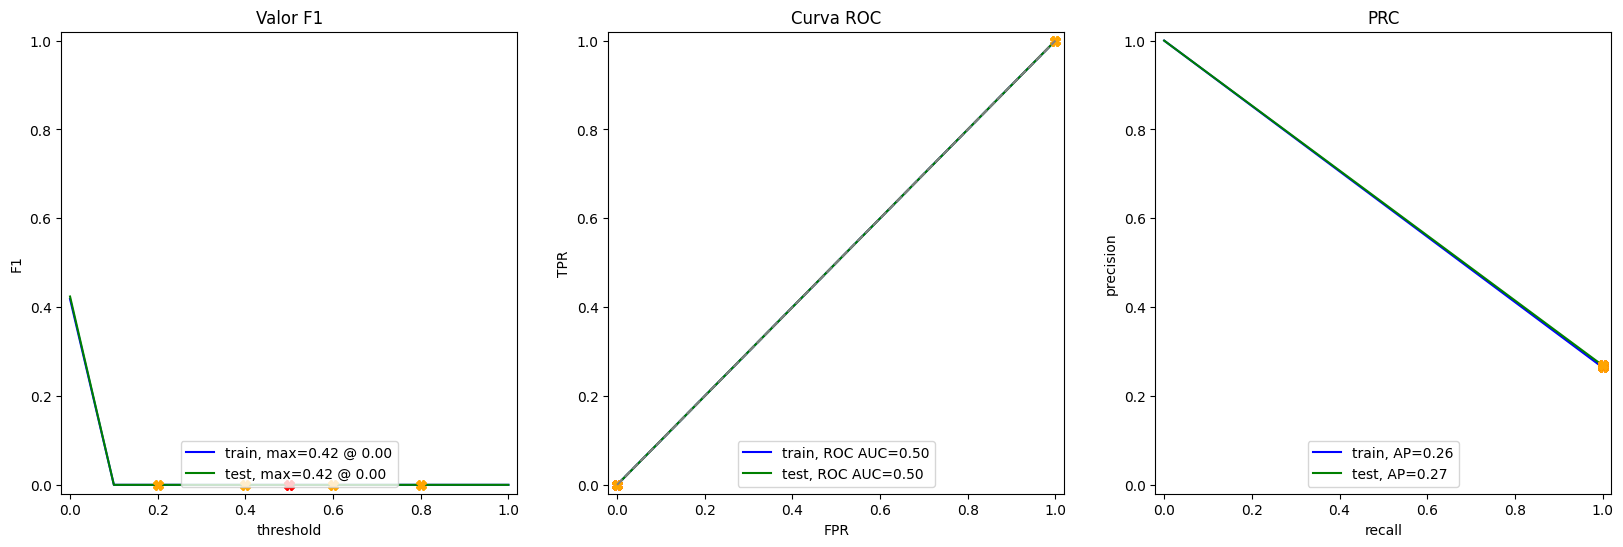

In [43]:
dummy_model = DummyClassifier(strategy='constant', constant=0)
dummy_model.fit(features_train, target_train)

evaluate_model(dummy_model, features_train, target_train, features_test, target_test, 'Modelo dummy')

Con la información del modelo dummy se pueden sentar bases para identificar y comparar los resultados de los demás modelos

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La organización del proceso de entrenamiento mediante funciones reutilizables aporta claridad y eficiencia al proyecto, además de facilitar una evaluación consistente de los modelos implementados.
</div>

### Regresión logística

In [51]:
# Establecimiento de los hiperparámetros del modelo para su ajuste
params_lr = {
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'C': [0.1, 1.0],
    'random_state': [12345]    
}

model_gridsearch(LogisticRegression(max_iter=1000), params_lr, features_train, target_train, 'regresión logística')

Mejores hiperparámetros regresión logística:
 {'C': 1.0, 'penalty': 'l2', 'random_state': 12345, 'solver': 'liblinear'}
Mejor AUC-ROC regresión logística: 0.8370616834032445


Regresión Logística:
               train    test
Exactitud     0.8007  0.8048
Sensibilidad  0.5315  0.5462
Precisión     0.6508  0.6677
F1            0.5851  0.6009
APS           0.6468  0.6495
ROC AUC       0.8407  0.8397


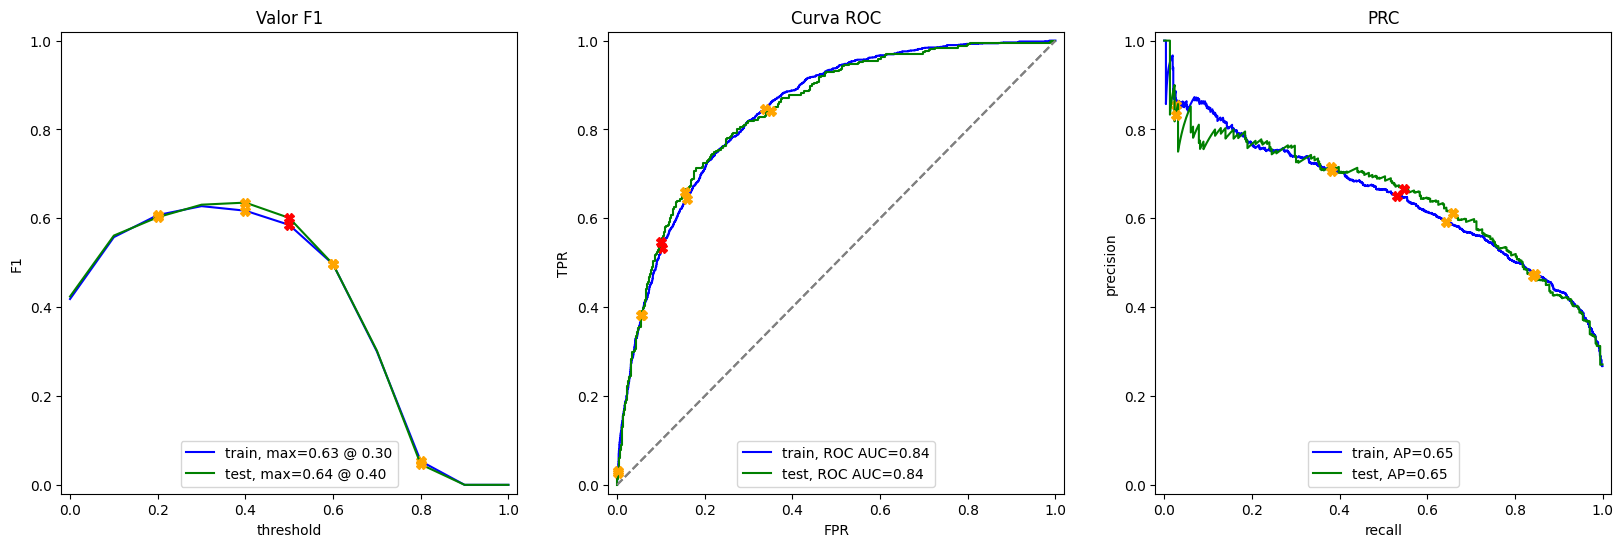

In [52]:
# entrenamiento del modelo con los mejores hiperparámetros
lr_model = LogisticRegression(random_state = 12345,
                              solver = 'liblinear',
                              penalty = 'l2',
                              C = 1.0,
                             )

lr_model.fit(features_train, target_train)

# evaluación del modelo
evaluate_model(lr_model, features_train, target_train, features_test, target_test, 'Regresión Logística')



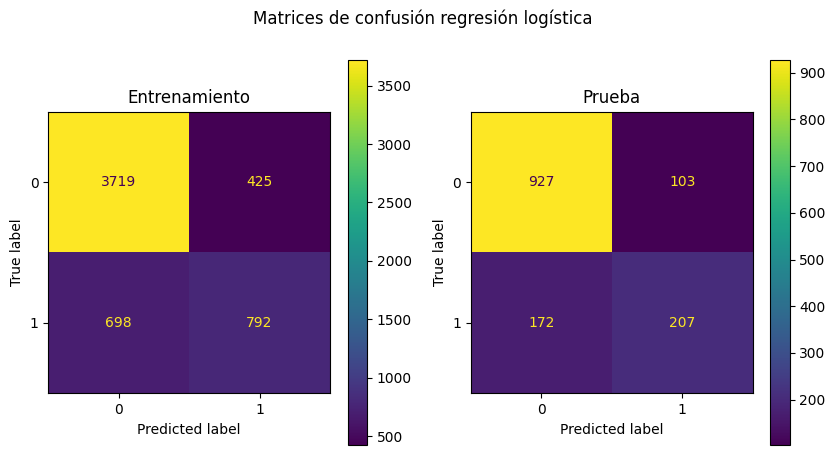

In [56]:
cf_matrix(lr_model, features_train, target_train, features_test, target_test, 'regresión logística')


- El modelo presenta una exactitud en el conjunto de prueba de 0.8048 y en el conjunto de entrenamiento de 0.8007.
- El modelo tiene una sensibilidad del 54% y una precisión del 66% 
- el modelo presenta la métrica de AUC-ROC en el conjunto de prueba de 0.8397 y en el conjunto de entrenamiento de 0.8407
- el modelo presenta una alta tasa de falsos negativos, lo que afecta el desempeño del mismo


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La implementación y evaluación de la regresión logística muestran un análisis sólido del desempeño del modelo, interpretando correctamente las métricas obtenidas y el comportamiento de la clasificación.
</div>

### Árbol de decisión

In [57]:
%%time
# Establecimiento de los hiperparámetros del modelo para su ajuste
params_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 16],
    'min_samples_leaf': [4, 6, 8, 16],
    'random_state': [12345]
}

model_gridsearch(DecisionTreeClassifier(), params_dt, features_train, target_train, 'árbol de decisión')


Mejores hiperparámetros árbol de decisión:
 {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 16, 'min_samples_split': 2, 'random_state': 12345}
Mejor AUC-ROC árbol de decisión: 0.8241272299059869
CPU times: user 16.6 s, sys: 0 ns, total: 16.6 s
Wall time: 16.6 s


Árbol de decisión:
               train    test
Exactitud     0.8033  0.7913
Sensibilidad  0.5463  0.5383
Precisión     0.6533  0.6316
F1            0.5950  0.5812
APS           0.6524  0.6033
ROC AUC       0.8569  0.8257


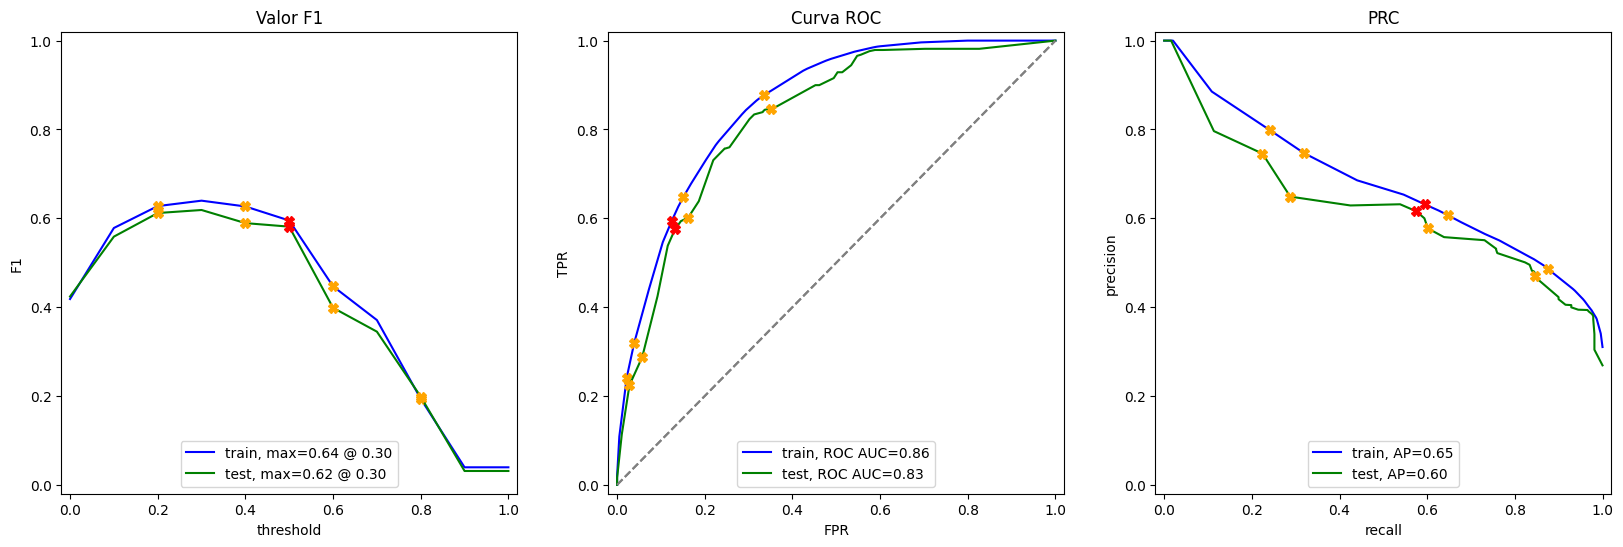

In [58]:
# entrenamiento del modelo con los mejores hiperparámetros
dt_model = DecisionTreeClassifier(random_state = 12345,
                              criterion = 'entropy',
                              max_depth = 6,
                              min_samples_leaf = 16,
                              min_samples_split = 2
                             )

dt_model.fit(features_train, target_train)

# evaluación del modelo
evaluate_model(dt_model, features_train, target_train, features_test, target_test, 'Árbol de decisión')

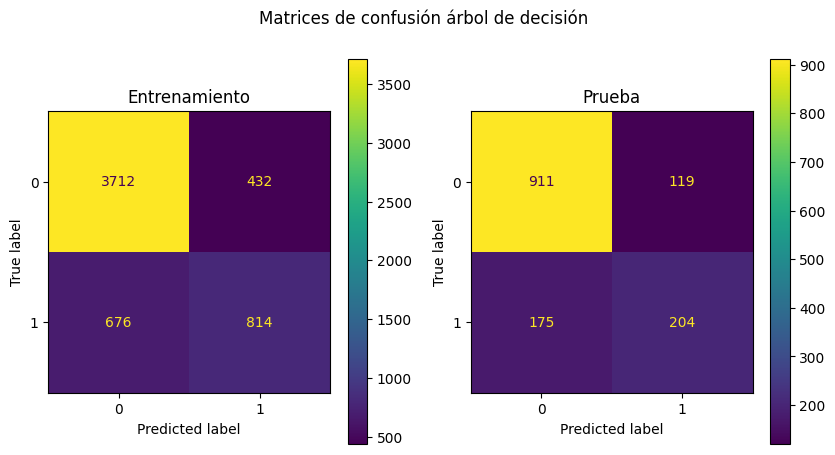

In [59]:
cf_matrix(dt_model, features_train, target_train, features_test, target_test, 'árbol de decisión')

- El modelo presenta una exactitud en el conjunto de prueba de 0.7913 y en el conjunto de entrenamiento de 0.8033.
- El modelo tiene una sensibilidad del 53.8% y una precisión del 63.16% 
- el modelo presenta la métrica de AUC-ROC en el conjunto de prueba de 0.8257 y en el conjunto de entrenamiento de 0.8569, lo que permite observar un sobreajuste 
- el modelo presenta una alta tasa de falsos negativos, lo que afecta el desempeño del mismo

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El árbol de decisión está evaluado con métricas pertinentes y la comparación entre entrenamiento y prueba permite identificar de forma clara el comportamiento del modelo frente al sobreajuste.
</div>

### Bosque aleatorio

In [60]:
%%time
# Establecimiento de los hiperparámetros del modelo para su ajuste
params_rf = {
    'criterion': ['gini', 'entropy'],
    'n_estimators': [10, 20, 30, 40, 50],
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_leaf': [10, 12, 14],
    'random_state': [12345]
}

model_gridsearch(RandomForestClassifier(), params_rf, features_train, target_train, 'bosque aleatorio')


Mejores hiperparámetros bosque aleatorio:
 {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 12, 'n_estimators': 50, 'random_state': 12345}
Mejor AUC-ROC bosque aleatorio: 0.8451063040699488
CPU times: user 56.2 s, sys: 0 ns, total: 56.2 s
Wall time: 56.2 s


Bosque aleatorio:
               train    test
Exactitud     0.8250  0.8034
Sensibilidad  0.5443  0.4987
Precisión     0.7254  0.6848
F1            0.6219  0.5771
APS           0.7355  0.6535
ROC AUC       0.8869  0.8441


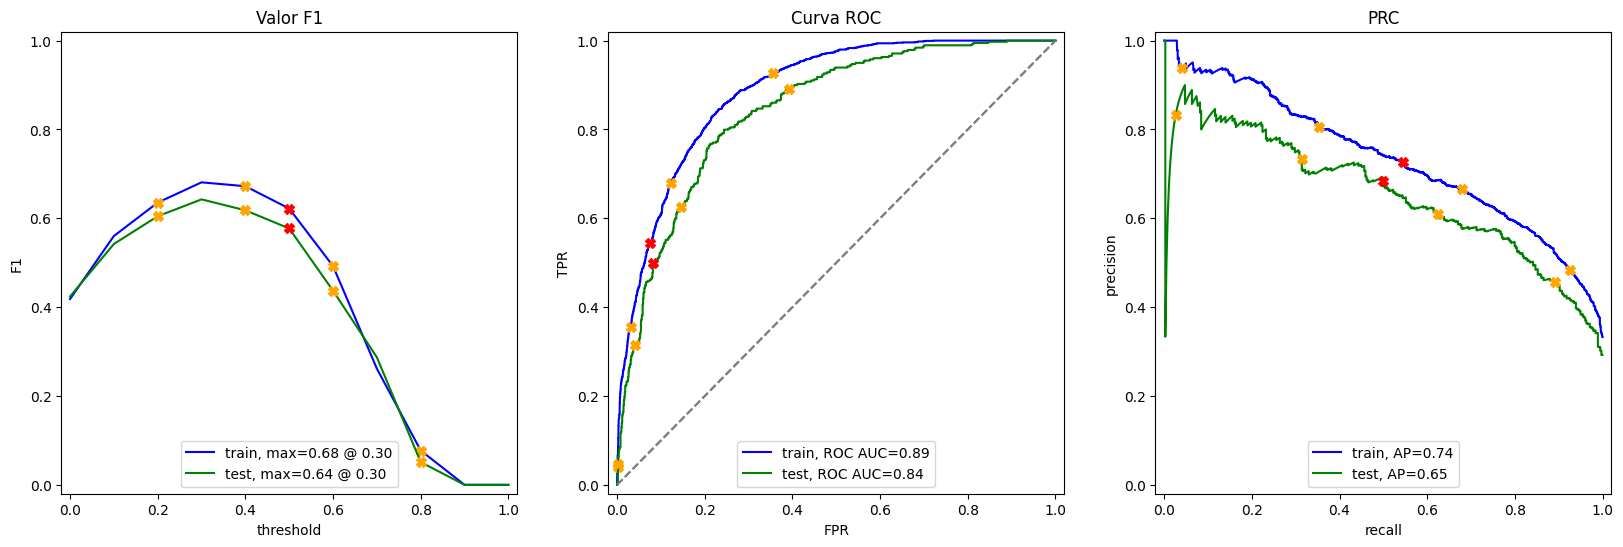

In [61]:
# entrenamiento del modelo con los mejores hiperparámetros
rf_model = RandomForestClassifier(random_state = 12345,
                              criterion = 'entropy',
                              max_depth = 10,
                              min_samples_leaf = 12,
                              n_estimators = 50
                             )

rf_model.fit(features_train, target_train)

# evaluación del modelo
evaluate_model(rf_model, features_train, target_train, features_test, target_test, 'Bosque aleatorio')

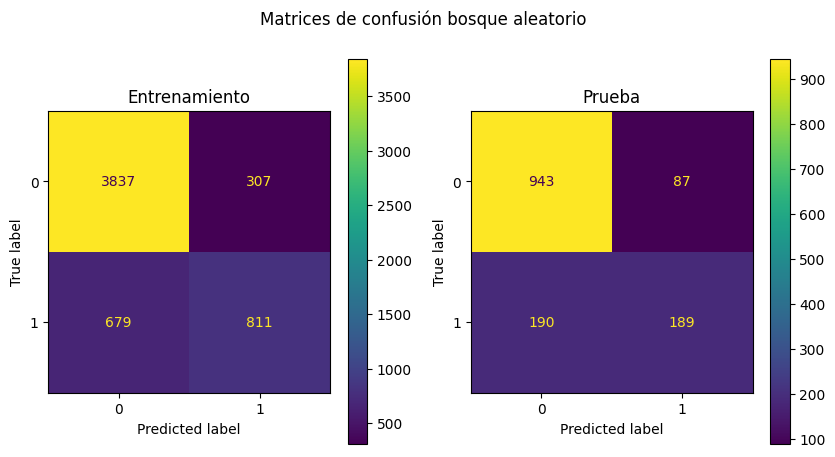

In [62]:
cf_matrix(rf_model, features_train, target_train, features_test, target_test, 'bosque aleatorio')


- El modelo presenta una exactitud en el conjunto de prueba de 0.8034 y en el conjunto de entrenamiento de 0.825.
- El modelo tiene una sensibilidad del 49.8% y una precisión del 68.4% 
- el modelo presenta la métrica de AUC-ROC en el conjunto de prueba de 0.8441 y en el conjunto de entrenamiento de 0.8869, lo que permite observar un sobreajuste 
- el modelo presenta una alta tasa de falsos negativos, lo que afecta el desempeño del mismo


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La evaluación del bosque aleatorio está bien organizada y permite comparar con claridad el rendimiento entre entrenamiento y prueba, incorporando métricas clave para valorar su desempeño predictivo.
</div>

### LightGBM

In [63]:
%%time
# Establecimiento de los hiperparámetros del modelo para su ajuste
params_lightgbm = {
    'objective': ['binary'],
    'num_leaves': [10, 20, 30],
    'learning_rate': [0.001, 0.1, 0.2, 0.5],
    'n_estimators': [100, 200, 500],
    'random_state': [12345]
}

model_gridsearch(LGBMClassifier(), params_lightgbm, features_train, target_train, 'LightGBM')


Mejores hiperparámetros LightGBM:
 {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 10, 'objective': 'binary', 'random_state': 12345}
Mejor AUC-ROC LightGBM: 0.8442143646524226
CPU times: user 4min, sys: 2.49 s, total: 4min 2s
Wall time: 2min 1s


LightGBM:
               train    test
Exactitud     0.8323  0.7999
Sensibilidad  0.5899  0.5092
Precisión     0.7246  0.6678
F1            0.6504  0.5778
APS           0.7484  0.6541
ROC AUC       0.8920  0.8407


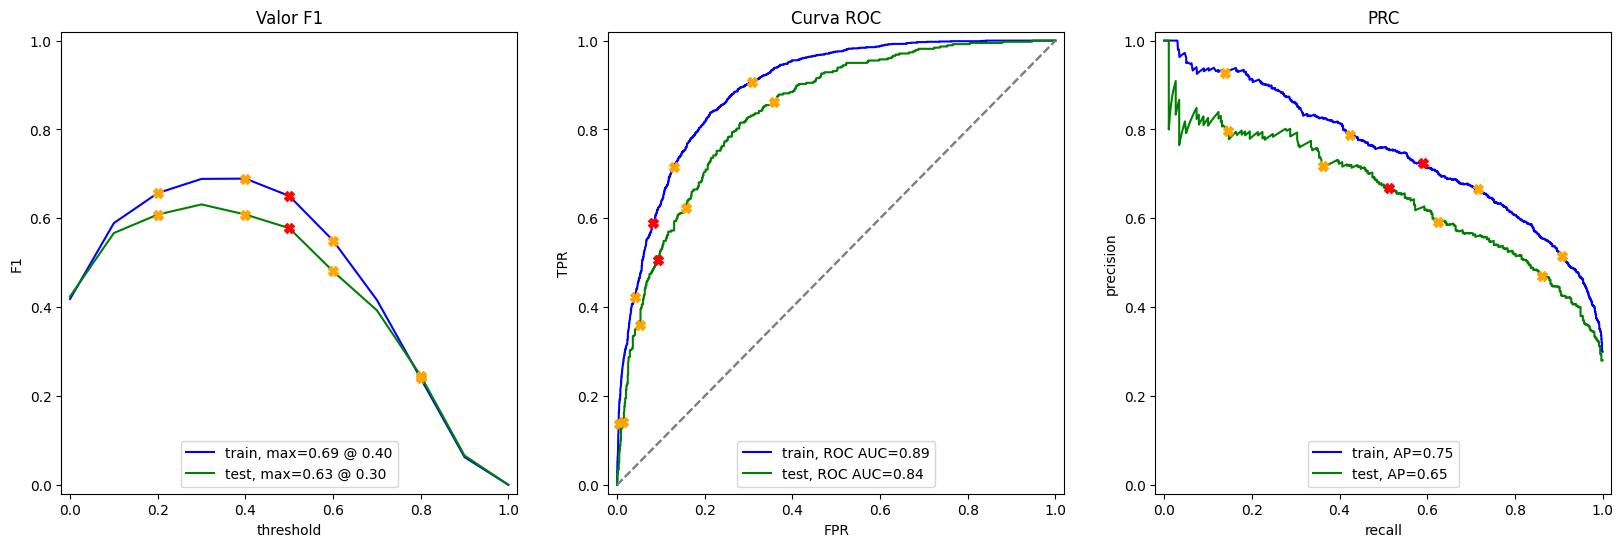

In [64]:
# entrenamiento del modelo con los mejores hiperparámetros
lightgbm_model = LGBMClassifier(random_state = 12345,
                              objective = 'binary',
                              num_leaves = 10,
                              learning_rate = 0.1,
                              n_estimators = 100
                             )

lightgbm_model.fit(features_train, target_train)

# evaluación del modelo
evaluate_model(lightgbm_model, features_train, target_train, features_test, target_test, 'LightGBM')

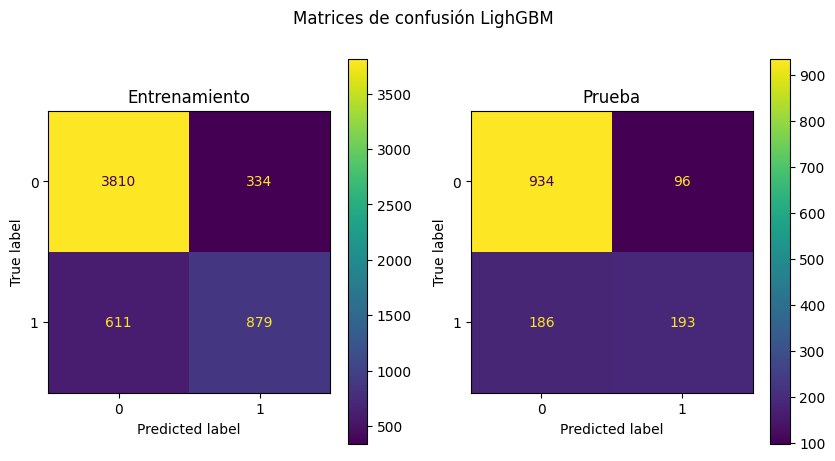

In [65]:
cf_matrix(lightgbm_model, features_train, target_train, features_test, target_test, 'LighGBM')

- El modelo presenta una exactitud en el conjunto de prueba de 0.7999 y en el conjunto de entrenamiento de 0.8323.
- El modelo tiene una sensibilidad del 50.9% y una precisión del 66.7% 
- el modelo presenta la métrica de AUC-ROC en el conjunto de prueba de 0.8407 y en el conjunto de entrenamiento de 0.892, lo que permite observar un sobreajuste 
- el modelo presenta una alta tasa de falsos negativos, lo que afecta el desempeño del mismo

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La implementación de LightGBM está bien integrada dentro del flujo de modelado y la interpretación de sus métricas permite valorar con claridad su rendimiento frente a los modelos anteriores.
</div>

### CatBoost

In [66]:
%%time
# Establecimiento de los hiperparámetros del modelo para su ajuste
params_catboost = {
    'depth': [4, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5]
}

catboost_est = CatBoostClassifier(iterations=100, 
                                  verbose=False, 
                                  loss_function='Logloss',
                                 eval_metric='AUC')

model_gridsearch(catboost_est, params_catboost, features_train, target_train, 'CatBoost')


Mejores hiperparámetros CatBoost:
 {'depth': 4, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Mejor AUC-ROC CatBoost: 0.8483219437896438
CPU times: user 3min 19s, sys: 29.7 s, total: 3min 48s
Wall time: 1min 59s


CatBoost:
               train    test
Exactitud     0.8177  0.8034
Sensibilidad  0.5416  0.5092
Precisión     0.7011  0.6796
F1            0.6111  0.5822
APS           0.7134  0.6605
ROC AUC       0.8710  0.8446


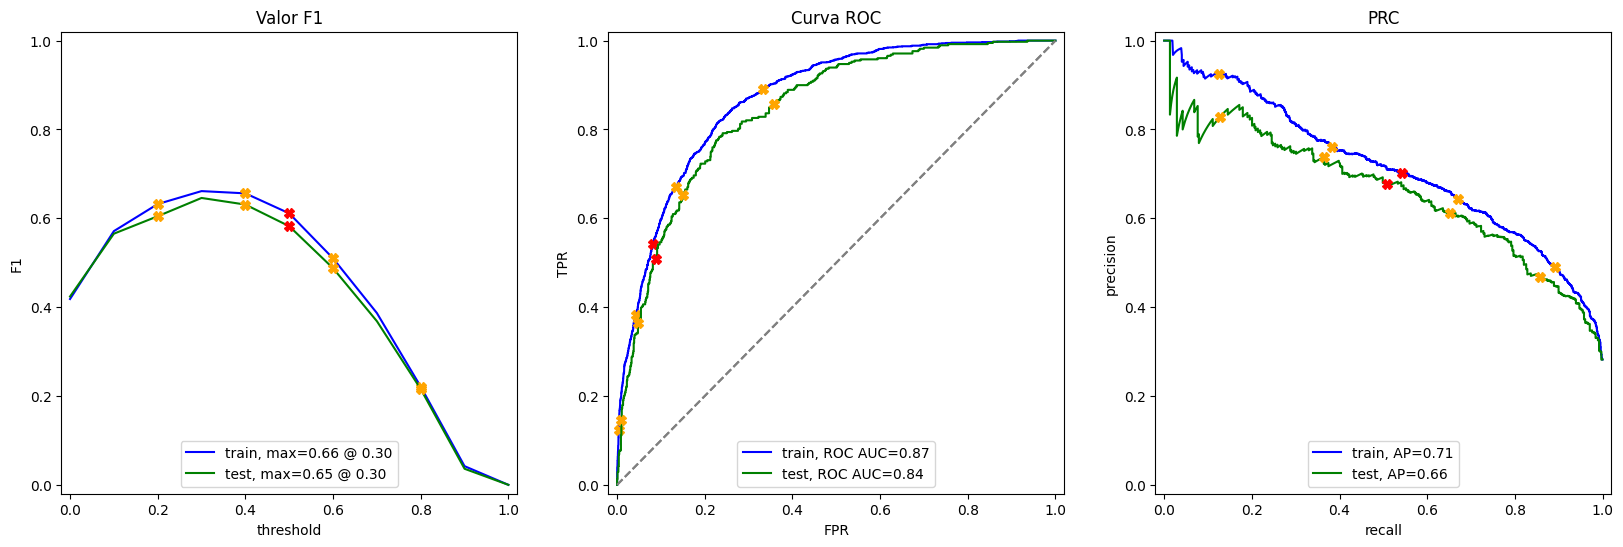

In [67]:
# entrenamiento del modelo con los mejores hiperparámetros
catboost_model = CatBoostClassifier(random_state = 12345,
                              iterations = 100,
                              loss_function='Logloss',
                              eval_metric='AUC',
                              depth=4,
                              l2_leaf_reg=1,
                              learning_rate=0.1,
                              verbose=False
                             )

catboost_model.fit(features_train, target_train, verbose=False)

# evaluación del modelo
evaluate_model(catboost_model, features_train, target_train, features_test, target_test, 'CatBoost')

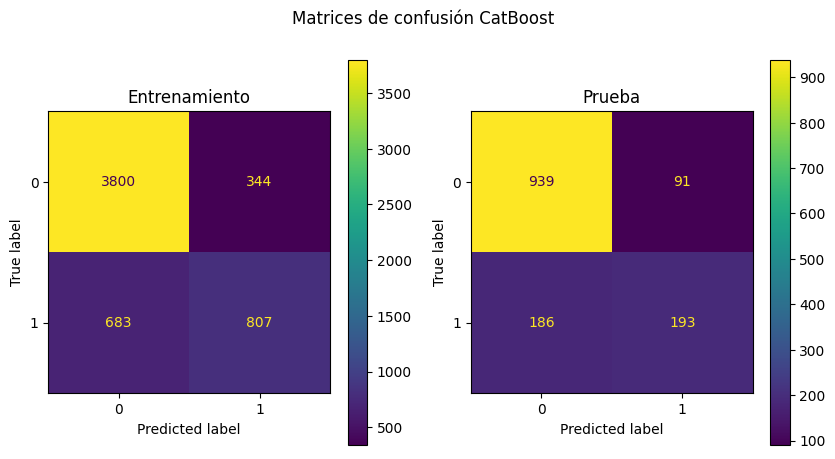

In [68]:
cf_matrix(catboost_model, features_train, target_train, features_test, target_test, 'CatBoost')


- El modelo presenta una exactitud en el conjunto de prueba de 0.8034 y en el conjunto de entrenamiento de 0.8177.
- El modelo tiene una sensibilidad del 50.9% y una precisión del 67.9% 
- el modelo presenta la métrica de AUC-ROC en el conjunto de prueba de 0.8446 y en el conjunto de entrenamiento de 0.871, lo que permite observar un sobreajuste 
- el modelo presenta una alta tasa de falsos negativos, lo que afecta el desempeño del mismo


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El entrenamiento de CatBoost está bien incorporado al proceso comparativo y la lectura de sus métricas muestra una evaluación cuidadosa del balance entre rendimiento, precisión y capacidad de generalización.
</div>

### XGBoost

In [69]:
#%%time
# Establecimiento de los hiperparámetros del modelo para su ajuste
#params_xgboost = {
#    'max_depth': [4, 6, 8],
#    'learning_rate': [0.01, 0.05, 0.1],
#    'n_estimators': [50, 100],
#    'gamma': [0, 0.5, 1],
#    'reg_alpha': [0, 0.5, 1],
#    'reg_lambda': [0.5, 1, 5],
#    'random_state': [12345]
#}

#model_gridsearch(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), params_xgboost, features_train, target_train, 'XGBoost')

Mejores hiperparámetros XGBoost:
 {'gamma': 1, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'random_state': 12345, 'reg_alpha': 1, 'reg_lambda': 5}
Mejor AUC-ROC XGBoost: 0.8482895596543717
CPU times: user 1h 24min 49s, sys: 9.08 s, total: 1h 24min 58s
Wall time: 42min 31s


XGBoost:
               train    test
Exactitud     0.8166  0.8048
Sensibilidad  0.5362  0.5013
Precisión     0.7003  0.6884
F1            0.6074  0.5802
APS           0.7080  0.6439
ROC AUC       0.8717  0.8416


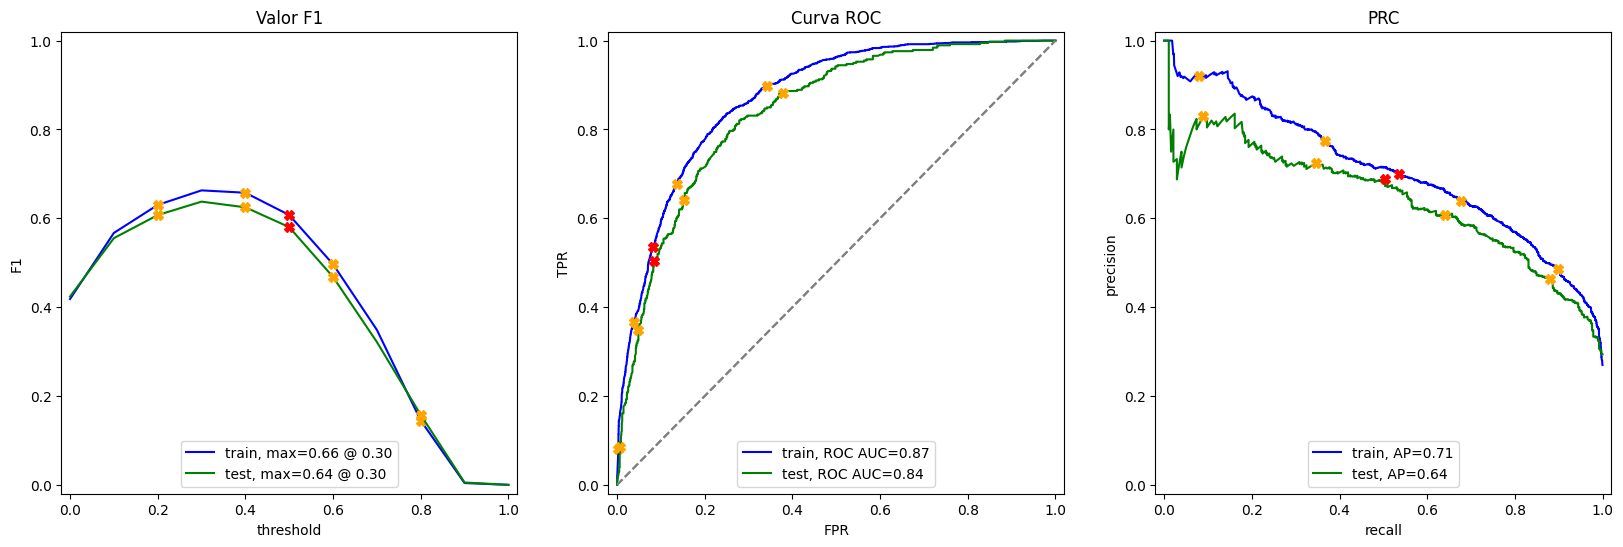

In [75]:
# entrenamiento del modelo con los mejores hiperparámetros
xgb_model = XGBClassifier(random_state = 12345,
                              max_depth = 4,
                              learning_rate = 0.1,
                              n_estimators = 50,
                              gamma= 1,
                              reg_alpha= 1,
                              reg_lambda= 5,
                              use_label_encoder=False,
                              eval_metric='logloss'
                             )

xgb_model.fit(features_train, target_train, verbose=False)

# evaluación del modelo
evaluate_model(xgb_model, features_train, target_train, features_test, target_test, 'XGBoost')

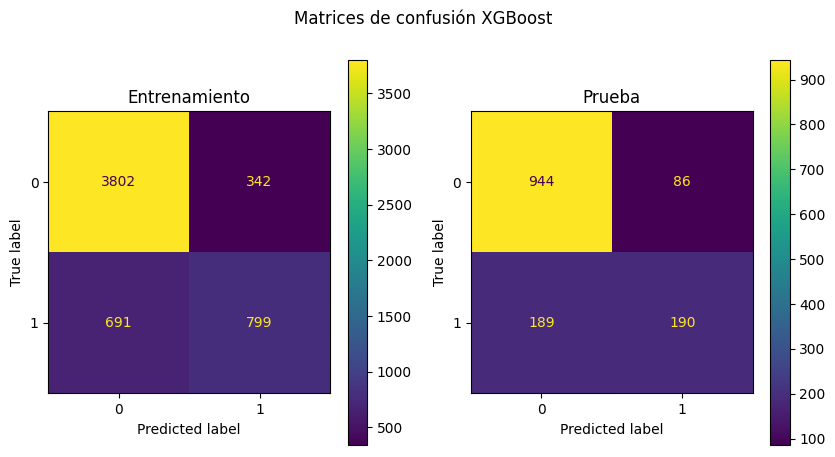

In [76]:
cf_matrix(xgb_model, features_train, target_train, features_test, target_test, 'XGBoost')

- El modelo presenta una exactitud en el conjunto de prueba de 0.8048 y en el conjunto de entrenamiento de 0.8166.
- El modelo tiene una sensibilidad del 50.1% y una precisión del 68.84% 
- el modelo presenta la métrica de AUC-ROC en el conjunto de prueba de 0.8416 y en el conjunto de entrenamiento de 0.871, lo que permite observar un sobreajuste 
- el modelo presenta una alta tasa de falsos negativos, lo que afecta el desempeño del mismo

In [78]:
# creación de tabla para mejor visualización y comparación de datos
results_table = pd.DataFrame({
    'modelo': ['Dummy', 'Regresión logística', 'Árbol de decisión', 'Bosque aleatorio', 'LightGBM', 'CatBoost', 'XGBoost'],
    'Exactitud_entrenamiento': [0.7355, 0.8007, 0.8033, 0.825, 0.8323, 0.8177, 0.8166],
    'Exactitud_prueba': [0.731, 0.8049, 0.7913, 0.8034, 0.7999, 0.8034, 0.8048],
    'auc_roc_entrenamiento': [0.5, 0.8407, 0.8569, 0.8869, 0.892, 0.871, 0.8717],
    'auc_roc_prueba': [0.5, 0.8397, 0.8257, 0.8441, 0.8407, 0.8446, 0.8416]
})
results_table

,modelo,Exactitud_entrenamiento,Exactitud_prueba,auc_roc_entrenamiento,auc_roc_prueba
0,Dummy,0.7355,0.7310,0.5000,0.5000
1,Regresión logística,0.8007,0.8049,0.8407,0.8397
2,Árbol de decisión,0.8033,0.7913,0.8569,0.8257
3,Bosque aleatorio,0.8250,0.8034,0.8869,0.8441
4,LightGBM,0.8323,0.7999,0.8920,0.8407
5,CatBoost,0.8177,0.8034,0.8710,0.8446
6,XGBoost,0.8166,0.8048,0.8717,0.8416


Con la creación de un dataframe con todos los datos se puede realizar una comparación de los mismos más directa, evitando errores en algún valor. Se determinó que todos los modelos utilizados superaron al modelo dummy y además, superaron el umbral de 0.8 en la métrica AUC-ROCPodemos determinar que tanto para la métrica de exactitud como para AUC-ROC en ambos conjuntos de datos.

Los modelos de potenciación de gradiente presentaron mejores resultados, aunque los modelos tradicionales (regresión lineal, árbol de decisión y bosque aleatorio) presentaron métricas con un valor significativo, pese a que se vio en todos los modelos un alto grado de falsos negativos.

Los modelos de potenciación de gradiente fueron los que más exigieron a la máquina, siendo el valor más alto el de XGBoost que para identificar los mejores hiperparámetros se demoró cerca de 43 minutos, mientras que LightGBM y CatBoost alrededor de 2 minutos, por lo que este modelo en una implementación posterior con una cantidad de datos mayor podría ser descartado.

En el caso de modelos de potenciación de gradiente, las métricas más altas correspondieron a LightGBM y CatBoost, con ligeras diferencias en los valores de métricas alcanzados. Es así que LightGBM alcanzó el valor AUC-ROC más alto, mientras que CatBoost presentó el valor de exactitud más elevado. Ambos modelos registraron un sobreajuste similar, sin embargo dado el tiempo que requiere el ajuste de hiperparámetros de CatBoost y XGBoost, consideramos que LightGBM fue el mejor modelo de potenciación.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La comparación final de modelos está bien sintetizada y permite identificar con claridad el desempeño relativo de cada alternativa, considerando tanto las métricas principales como el tiempo de entrenamiento.
</div>

## Conclusiones

Se construyeron seis modelos de aprendizaje automático para una tarea de clasificación binaria, a partir de un dataframe consolidado por 4 df, cuyos datos se codificaron y estandarizaron para que la información que traían fuera valiosa para cada uno de los modelos. Se dividió el dataset en conjuntos de entrenamiento y prueba en una proporción 80:20. Se registró un desbalance de clases, con una tasa de cancelación del 26%, la cual se decidió mantener este desbalance para que cada modelo aprendiera a identificar la salida de clientes correctamente. Todos los modelos tuvieron un AUC-ROC mayor o igual a 0.8.

Los modelos tradicionales de Regresión Logística, Árbol de Decisión y Bosque Aleatorio fueron los que registraron las métricas AUC-ROC más bajas o justo por encima del umbral, siendo el modelo de Bosque Aleatorio el que presentó la métrica más alta, incluso superando valores de algunos modelos de potenciación de gradiente. Con respecto a estos últimos, generaron las mejores métricas, siendo CatBoost el de mejor desempeño, seguido por el bosque aleatorio.

Los valores de exactitud fueron de alrededor del 80% para todos los modelos. Si bien la métrica alcanzada pasa la prueba de cordura, esto no se vio reflejado al analizar las matrices de confusión y gráficos correspondientes de cada modelo, ya que todos tenían una alta tasa de falsos negativos

Con respecto a los mejores modelos fueron CatBoost y LightGBM para las métricas evaluadas, ambos presentando un tiempo de identificación de los mejores hiperparámetros muy similar de cerca de 2 minutos.

## Recomendación para la empresa

Con un AUC-ROC mayor al 84% y una exactitud del 80%, el modelo podrá detectar aquellos clientes que tienen una mayor probabilidad de abandonar sus cuentas, permitiendo que anuncios u ofertas de planes y códigos promocionales lleguen a los usuarios correctos, disminuyendo gastos en estrategias de marketing e incrementado los ingresos de la empresa a largo plazo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Las conclusiones integran adecuadamente los resultados obtenidos y reflejan una interpretación clara del impacto práctico de los modelos desarrollados dentro del contexto del negocio.
</div>

# Comentario General del Revisor


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

El proyecto presenta un desarrollo completo y bien estructurado para abordar el problema de cancelación de clientes mediante modelos de clasificación. A lo largo del notebook se evidencia una secuencia lógica de trabajo, comenzando desde la exploración inicial de los datos hasta la comparación final de modelos y la generación de conclusiones orientadas al negocio.

#### Puntos Positivos:

- **Carga y exploración de datos:**  
Se realizó una revisión detallada de cada uno de los datasets, verificando dimensiones, tipos de datos, valores ausentes, duplicados y comportamiento de las variables. Las interpretaciones realizadas después de cada visualización aportan contexto y muestran comprensión de la información analizada.

- **Procesamiento y limpieza de datos:**  
La unificación de los cuatro datasets fue implementada correctamente utilizando `merge`, conservando la información necesaria para el análisis. El tratamiento de valores ausentes fue coherente con la lógica del problema, especialmente en variables relacionadas con servicios no contratados y en la construcción de la variable objetivo.

- **Preparación de variables:**  
La aplicación de codificación One-Hot Encoding y la normalización mediante `StandardScaler` fueron ejecutadas adecuadamente, dejando el conjunto de datos listo para el entrenamiento de modelos de machine learning.

- **Construcción de modelos:**  
Se implementaron correctamente distintos algoritmos de clasificación:
  - Regresión Logística
  - Árbol de Decisión
  - Bosque Aleatorio
  - LightGBM
  - CatBoost
  - XGBoost
  - Modelo Dummy para comparación base

Además, se utilizaron procesos de búsqueda de hiperparámetros mediante `GridSearchCV`, lo cual fortalece significativamente la calidad técnica del proyecto.

- **Evaluación de modelos:**  
Las métricas seleccionadas fueron apropiadas para el problema planteado. Se evaluaron:
  - Exactitud
  - Precisión
  - Sensibilidad
  - F1-score
  - APS
  - AUC-ROC

También se incluyeron curvas, ROC, PRC, análisis de umbrales y matrices de confusión, permitiendo una evaluación mucho más completa del desempeño de cada modelo.

- **Comparación e interpretación:**  
La tabla comparativa final facilita identificar diferencias entre modelos y justificar la selección del mejor algoritmo. La interpretación de métricas, tiempos de entrenamiento y presencia de sobreajuste demuestra una lectura crítica de los resultados obtenidos.



- **Conclusiones y enfoque de negocio:**  
Las conclusiones conectan adecuadamente el desempeño técnico de los modelos con una posible aplicación empresarial, explicando cómo la predicción de cancelación puede contribuir a mejorar estrategias de retención de clientes y optimización de campañas.

El trabajo refleja un manejo sólido del flujo completo de un proyecto de machine learning aplicado a análisis de clientes, integrando correctamente preparación de datos, modelado, evaluación y análisis de resultados.
</div>

